In [1]:
!pip install mediapipe opencv-python

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import mediapipe as mp

In [3]:
from google.colab import files

uploaded = files.upload()

Saving P1043106_720.mp4 to P1043106_720 (1).mp4


In [4]:
video_path = "P1043106_720.mp4"

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("ERROR: Could not open video")
else:
    print("Video loaded successfully!")

fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

duration = frame_count / fps

print("FPS:", fps)
print("Number of frames:", frame_count)
print("Resolution:", width, "x", height)
print("Duration:", round(duration, 2), "seconds")

cap.release()

Video loaded successfully!
FPS: 25.0
Number of frames: 3100
Resolution: 1280 x 720
Duration: 124.0 seconds


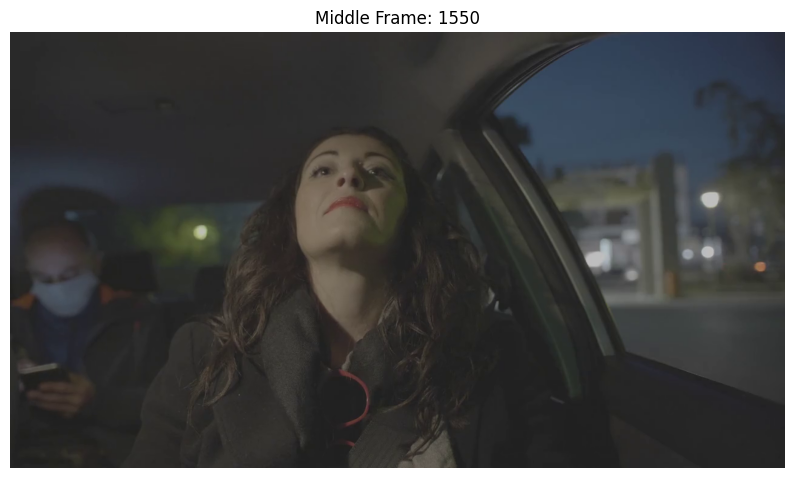

In [5]:
cap = cv2.VideoCapture(video_path)

middle_frame = frame_count // 2
cap.set(cv2.CAP_PROP_POS_FRAMES, middle_frame)

success, frame = cap.read()
cap.release()

if success:
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 6))
    plt.imshow(frame_rgb)
    plt.title(f"Middle Frame: {middle_frame}")
    plt.axis("off")
    plt.show()
else:
    print("Could not read frame.")

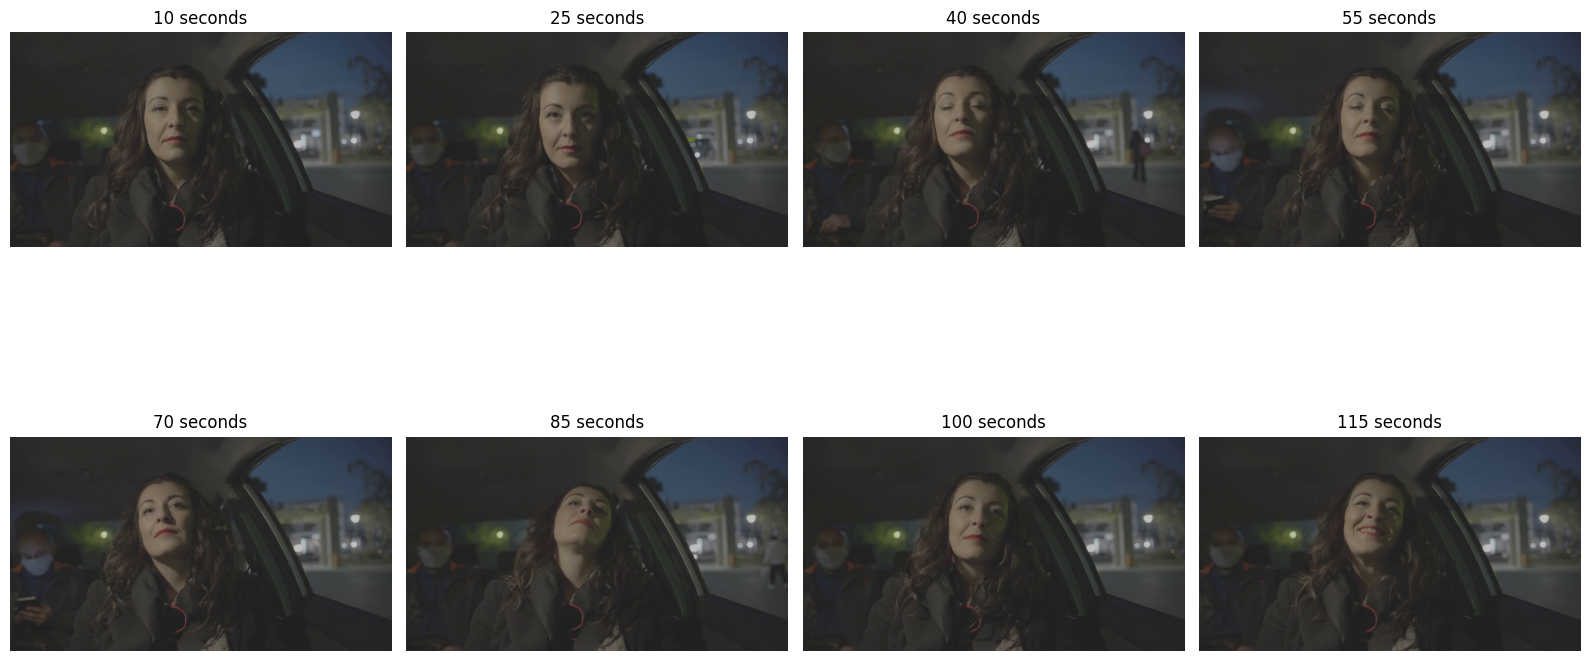

In [6]:
cap = cv2.VideoCapture(video_path)

# Times in seconds that we want to inspect
times = [10, 25, 40, 55, 70, 85, 100, 115]

plt.figure(figsize=(16, 10))

for i, t in enumerate(times):

    # Convert seconds to frame number
    frame_number = int(t * fps)

    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number)

    success, frame = cap.read()

    if success:
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        plt.subplot(2, 4, i + 1)
        plt.imshow(frame_rgb)
        plt.title(f"{t} seconds")
        plt.axis("off")

cap.release()

plt.tight_layout()
plt.show()

In [7]:
# Choose a clear frame at 25 seconds
test_time = 25

cap = cv2.VideoCapture(video_path)
cap.set(cv2.CAP_PROP_POS_MSEC, test_time * 1000)

success, frame = cap.read()
cap.release()

if not success:
    print("Could not read frame")

In [8]:
# MediaPipe Face Landmark Detection - compatible with current MediaPipe

import urllib.request
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# Download Face Landmarker model
model_path = "face_landmarker.task"

model_url = (
    "https://storage.googleapis.com/mediapipe-models/"
    "face_landmarker/face_landmarker/float16/1/face_landmarker.task"
)

urllib.request.urlretrieve(model_url, model_path)

# Create Face Landmarker
base_options = python.BaseOptions(model_asset_path=model_path)

options = vision.FaceLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.IMAGE,
    num_faces=1,
    min_face_detection_confidence=0.5,
    min_face_presence_confidence=0.5,
    min_tracking_confidence=0.5
)

face_landmarker = vision.FaceLandmarker.create_from_options(options)

# Convert OpenCV frame from BGR to RGB
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

# Convert NumPy image into MediaPipe Image
mp_image = mp.Image(
    image_format=mp.ImageFormat.SRGB,
    data=frame_rgb
)

# Detect facial landmarks
results = face_landmarker.detect(mp_image)

# Check result
if results.face_landmarks:
    print("Face detected!")
    print("Number of landmarks:",
          len(results.face_landmarks[0]))
else:
    print("No face detected.")

Face detected!
Number of landmarks: 478


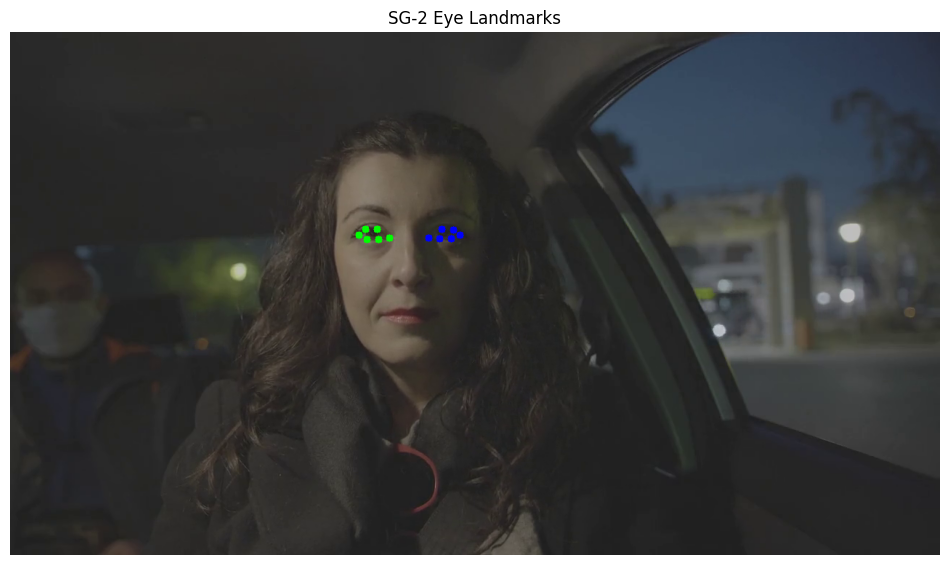

In [9]:
# MediaPipe eye landmark indices
LEFT_EYE = [33, 160, 158, 133, 153, 144]
RIGHT_EYE = [362, 385, 387, 263, 373, 380]

# Make a copy of the frame
eye_frame = frame.copy()

h, w, _ = eye_frame.shape

# Get detected face landmarks
landmarks = results.face_landmarks[0]

# Draw LEFT eye landmarks
for idx in LEFT_EYE:
    landmark = landmarks[idx]

    x = int(landmark.x * w)
    y = int(landmark.y * h)

    cv2.circle(eye_frame, (x, y), 5, (0, 255, 0), -1)


# Draw RIGHT eye landmarks
for idx in RIGHT_EYE:
    landmark = landmarks[idx]

    x = int(landmark.x * w)
    y = int(landmark.y * h)

    cv2.circle(eye_frame, (x, y), 5, (255, 0, 0), -1)


# Convert BGR → RGB for matplotlib
eye_frame_rgb = cv2.cvtColor(eye_frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 7))
plt.imshow(eye_frame_rgb)
plt.title("SG-2 Eye Landmarks")
plt.axis("off")
plt.show()

In [10]:
# Function to calculate Euclidean distance
def euclidean_distance(point1, point2):
    return np.linalg.norm(np.array(point1) - np.array(point2))


# Function to calculate EAR
def calculate_ear(landmarks, eye_indices, width, height):

    # Convert MediaPipe landmarks into pixel coordinates
    points = []

    for idx in eye_indices:
        landmark = landmarks[idx]

        x = landmark.x * width
        y = landmark.y * height

        points.append((x, y))

    # EAR distances
    vertical_1 = euclidean_distance(points[1], points[5])
    vertical_2 = euclidean_distance(points[2], points[4])

    horizontal = euclidean_distance(points[0], points[3])

    # EAR formula
    ear = (vertical_1 + vertical_2) / (2.0 * horizontal)

    return ear


# Calculate left and right EAR
left_ear = calculate_ear(
    landmarks,
    LEFT_EYE,
    w,
    h
)

right_ear = calculate_ear(
    landmarks,
    RIGHT_EYE,
    w,
    h
)

# Average both eyes
average_ear = (left_ear + right_ear) / 2


print("Left EAR :", round(left_ear, 3))
print("Right EAR:", round(right_ear, 3))
print("Average EAR:", round(average_ear, 3))

Left EAR : 0.322
Right EAR: 0.305
Average EAR: 0.314


Time: 40 seconds
Left EAR : 0.077
Right EAR: 0.058
Average EAR: 0.068


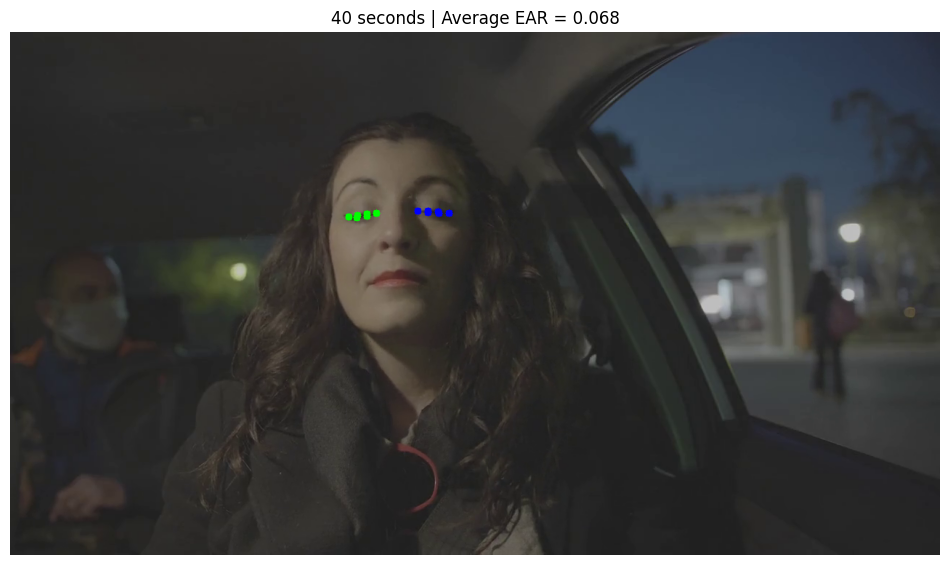

In [11]:
# ==========================================
# TEST EAR AT 40 SECONDS
# ==========================================

test_time = 40

# Read frame at 40 seconds
cap = cv2.VideoCapture(video_path)
cap.set(cv2.CAP_PROP_POS_MSEC, test_time * 1000)

success, closed_frame = cap.read()
cap.release()

if not success:
    print("Could not read frame.")

else:
    # Convert to RGB
    closed_rgb = cv2.cvtColor(closed_frame, cv2.COLOR_BGR2RGB)

    # Convert to MediaPipe image
    mp_image_closed = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=closed_rgb
    )

    # Detect landmarks
    closed_results = face_landmarker.detect(mp_image_closed)

    if closed_results.face_landmarks:

        closed_landmarks = closed_results.face_landmarks[0]

        h_closed, w_closed, _ = closed_frame.shape

        # Calculate EAR
        left_ear_closed = calculate_ear(
            closed_landmarks,
            LEFT_EYE,
            w_closed,
            h_closed
        )

        right_ear_closed = calculate_ear(
            closed_landmarks,
            RIGHT_EYE,
            w_closed,
            h_closed
        )

        avg_ear_closed = (
            left_ear_closed + right_ear_closed
        ) / 2

        print("Time:", test_time, "seconds")
        print("Left EAR :", round(left_ear_closed, 3))
        print("Right EAR:", round(right_ear_closed, 3))
        print("Average EAR:", round(avg_ear_closed, 3))

        # Draw eye landmarks
        display_frame = closed_frame.copy()

        for idx in LEFT_EYE:
            lm = closed_landmarks[idx]

            x = int(lm.x * w_closed)
            y = int(lm.y * h_closed)

            cv2.circle(
                display_frame,
                (x, y),
                5,
                (0, 255, 0),
                -1
            )

        for idx in RIGHT_EYE:
            lm = closed_landmarks[idx]

            x = int(lm.x * w_closed)
            y = int(lm.y * h_closed)

            cv2.circle(
                display_frame,
                (x, y),
                5,
                (255, 0, 0),
                -1
            )

        # Display frame
        display_rgb = cv2.cvtColor(
            display_frame,
            cv2.COLOR_BGR2RGB
        )

        plt.figure(figsize=(12, 7))
        plt.imshow(display_rgb)
        plt.title(
            f"40 seconds | Average EAR = {avg_ear_closed:.3f}"
        )
        plt.axis("off")
        plt.show()

    else:
        print("Face not detected at 40 seconds.")

In [12]:
# ==========================================
# FAST VIDEO EAR PROCESSING
# Process every 5th frame
# ==========================================

import pandas as pd

cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

SKIP = 5

frame_number = 0
processed_count = 0
ear_data = []

while True:

    success, current_frame = cap.read()

    if not success:
        break

    # Only process every 5th frame
    if frame_number % SKIP != 0:
        frame_number += 1
        continue

    timestamp = frame_number / fps

    # Resize to speed up MediaPipe
    small_frame = cv2.resize(
        current_frame,
        None,
        fx=0.5,
        fy=0.5
    )

    rgb_frame = cv2.cvtColor(
        small_frame,
        cv2.COLOR_BGR2RGB
    )

    mp_frame = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=rgb_frame
    )

    detection = face_landmarker.detect(mp_frame)

    if detection.face_landmarks:

        lm = detection.face_landmarks[0]

        h_frame, w_frame, _ = small_frame.shape

        left = calculate_ear(
            lm,
            LEFT_EYE,
            w_frame,
            h_frame
        )

        right = calculate_ear(
            lm,
            RIGHT_EYE,
            w_frame,
            h_frame
        )

        average = (left + right) / 2

        valid = True

    else:

        left = np.nan
        right = np.nan
        average = np.nan
        valid = False

    ear_data.append({
        "frame": frame_number,
        "time_sec": timestamp,
        "left_ear": left,
        "right_ear": right,
        "average_ear": average,
        "valid": valid
    })

    processed_count += 1

    if processed_count % 100 == 0:
        print(
            f"Processed {processed_count} samples "
            f"(video frame {frame_number}/{total_frames})"
        )

    frame_number += 1


cap.release()

ear_df = pd.DataFrame(ear_data)

print("\nDONE!")
print("Samples processed:", len(ear_df))
print("Valid samples:", ear_df["valid"].sum())
print("Invalid samples:", (~ear_df["valid"]).sum())

Processed 100 samples (video frame 495/3100)
Processed 200 samples (video frame 995/3100)
Processed 300 samples (video frame 1495/3100)
Processed 400 samples (video frame 1995/3100)
Processed 500 samples (video frame 2495/3100)
Processed 600 samples (video frame 2995/3100)

DONE!
Samples processed: 620
Valid samples: 612
Invalid samples: 8


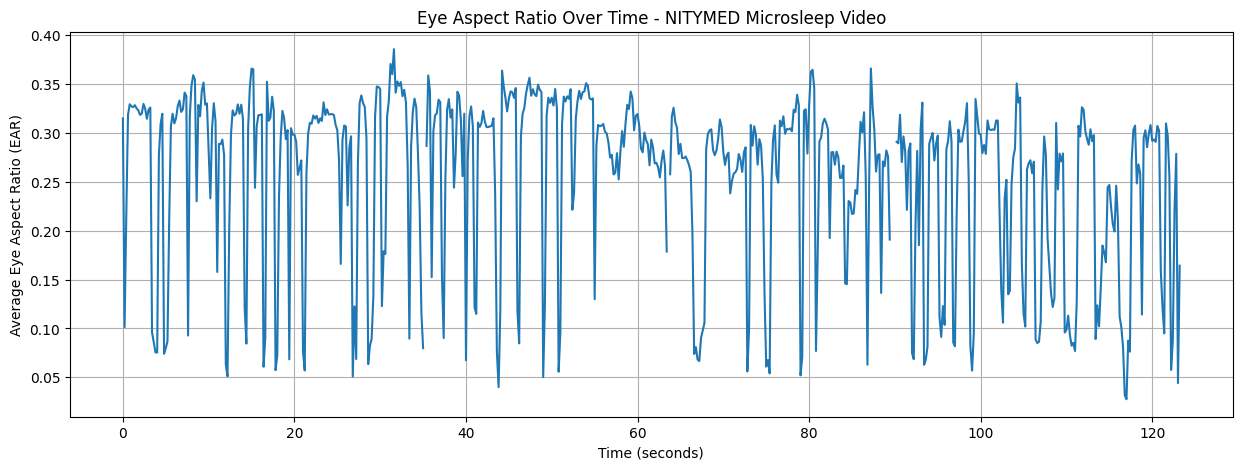

In [13]:
plt.figure(figsize=(15, 5))

plt.plot(
    ear_df["time_sec"],
    ear_df["average_ear"]
)

plt.xlabel("Time (seconds)")
plt.ylabel("Average Eye Aspect Ratio (EAR)")
plt.title("Eye Aspect Ratio Over Time - NITYMED Microsleep Video")

plt.grid(True)
plt.show()

In [14]:
# ==========================================
# CREATE 40 TEST FRAMES FOR MANUAL LABELLING
# ==========================================

test_times = np.linspace(2, 122, 40)

cap = cv2.VideoCapture(video_path)

test_images = []

for t in test_times:

    cap.set(cv2.CAP_PROP_POS_MSEC, t * 1000)

    success, test_frame = cap.read()

    if success:
        test_images.append((t, test_frame))

cap.release()

print("Test frames extracted:", len(test_images))

Test frames extracted: 40


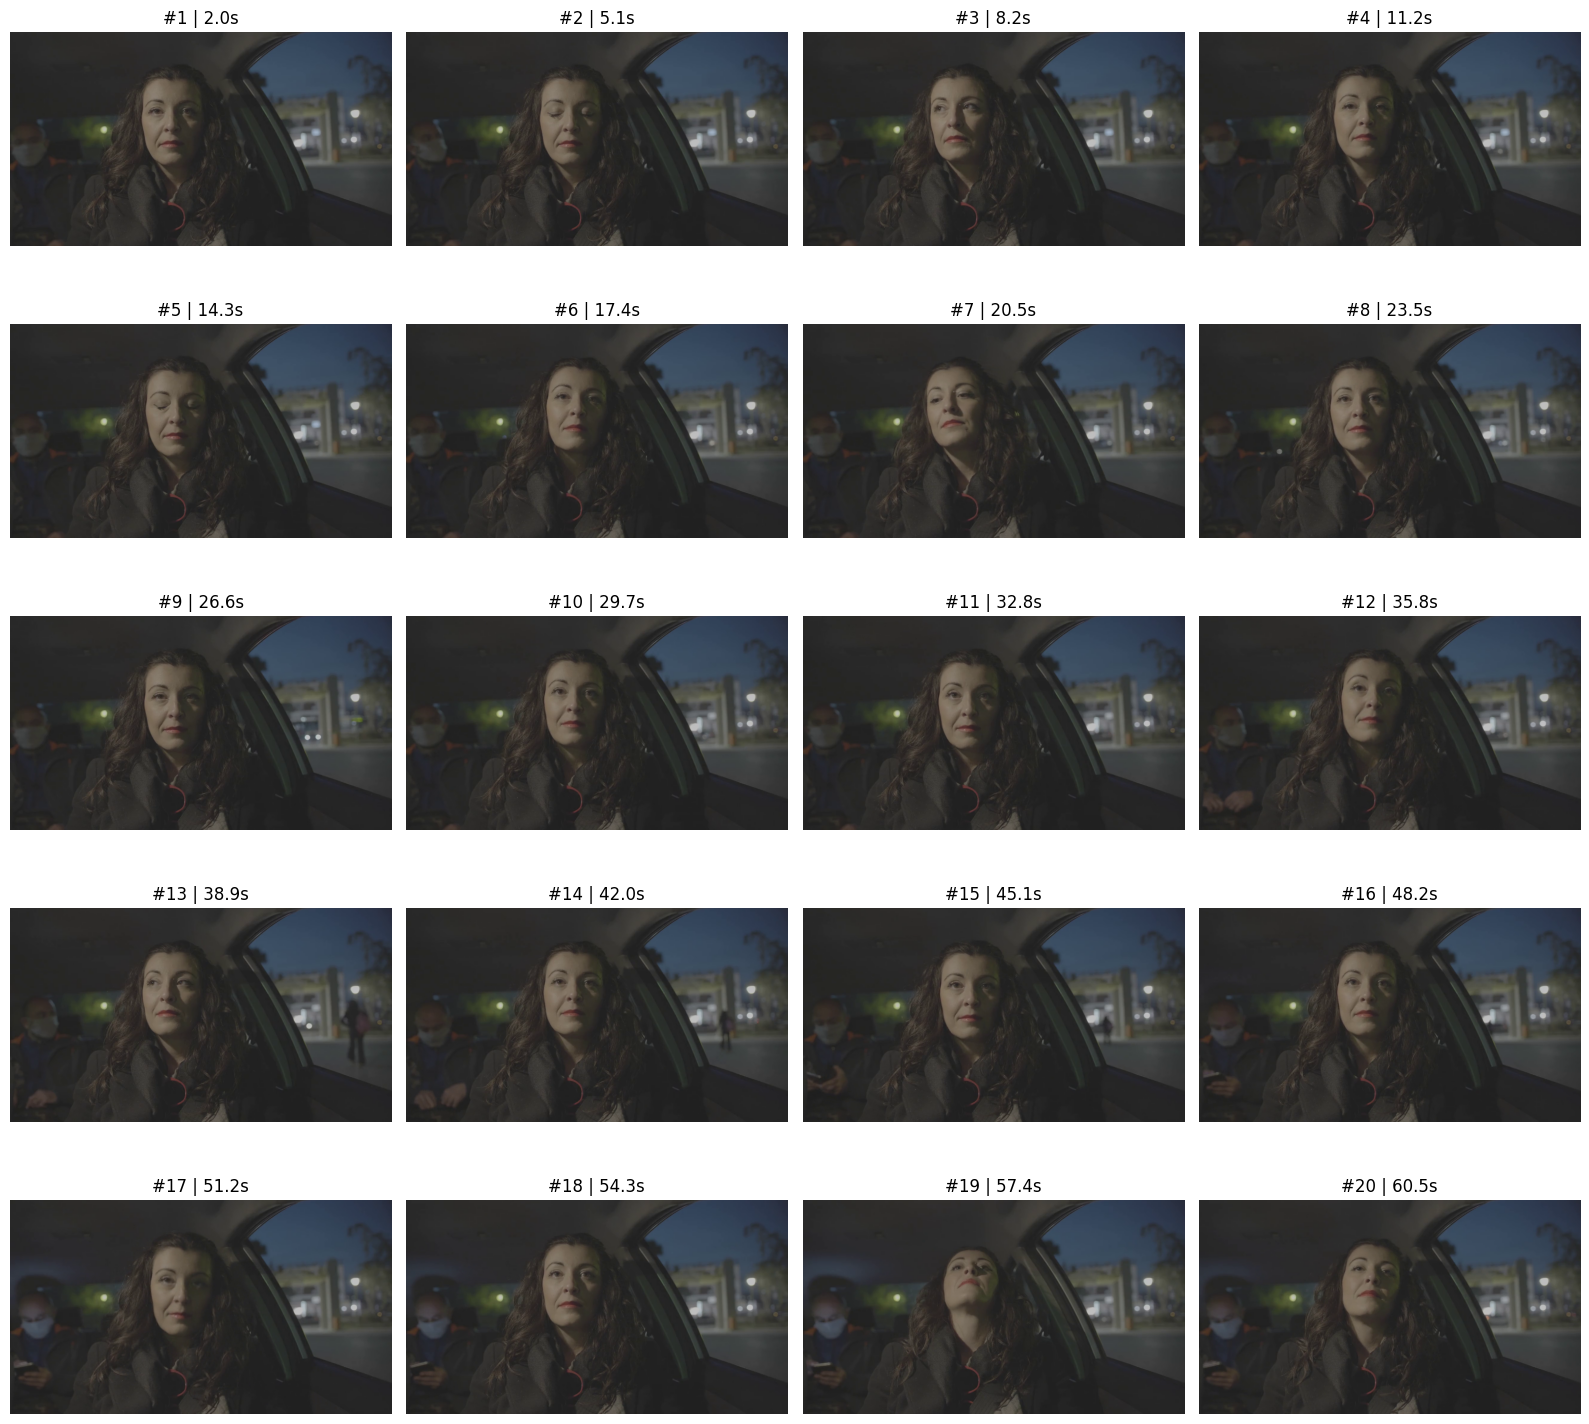

In [15]:
plt.figure(figsize=(16, 15))

for i, (t, img) in enumerate(test_images[:20]):

    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(5, 4, i + 1)
    plt.imshow(rgb)
    plt.title(f"#{i+1} | {t:.1f}s")
    plt.axis("off")

plt.tight_layout()
plt.show()

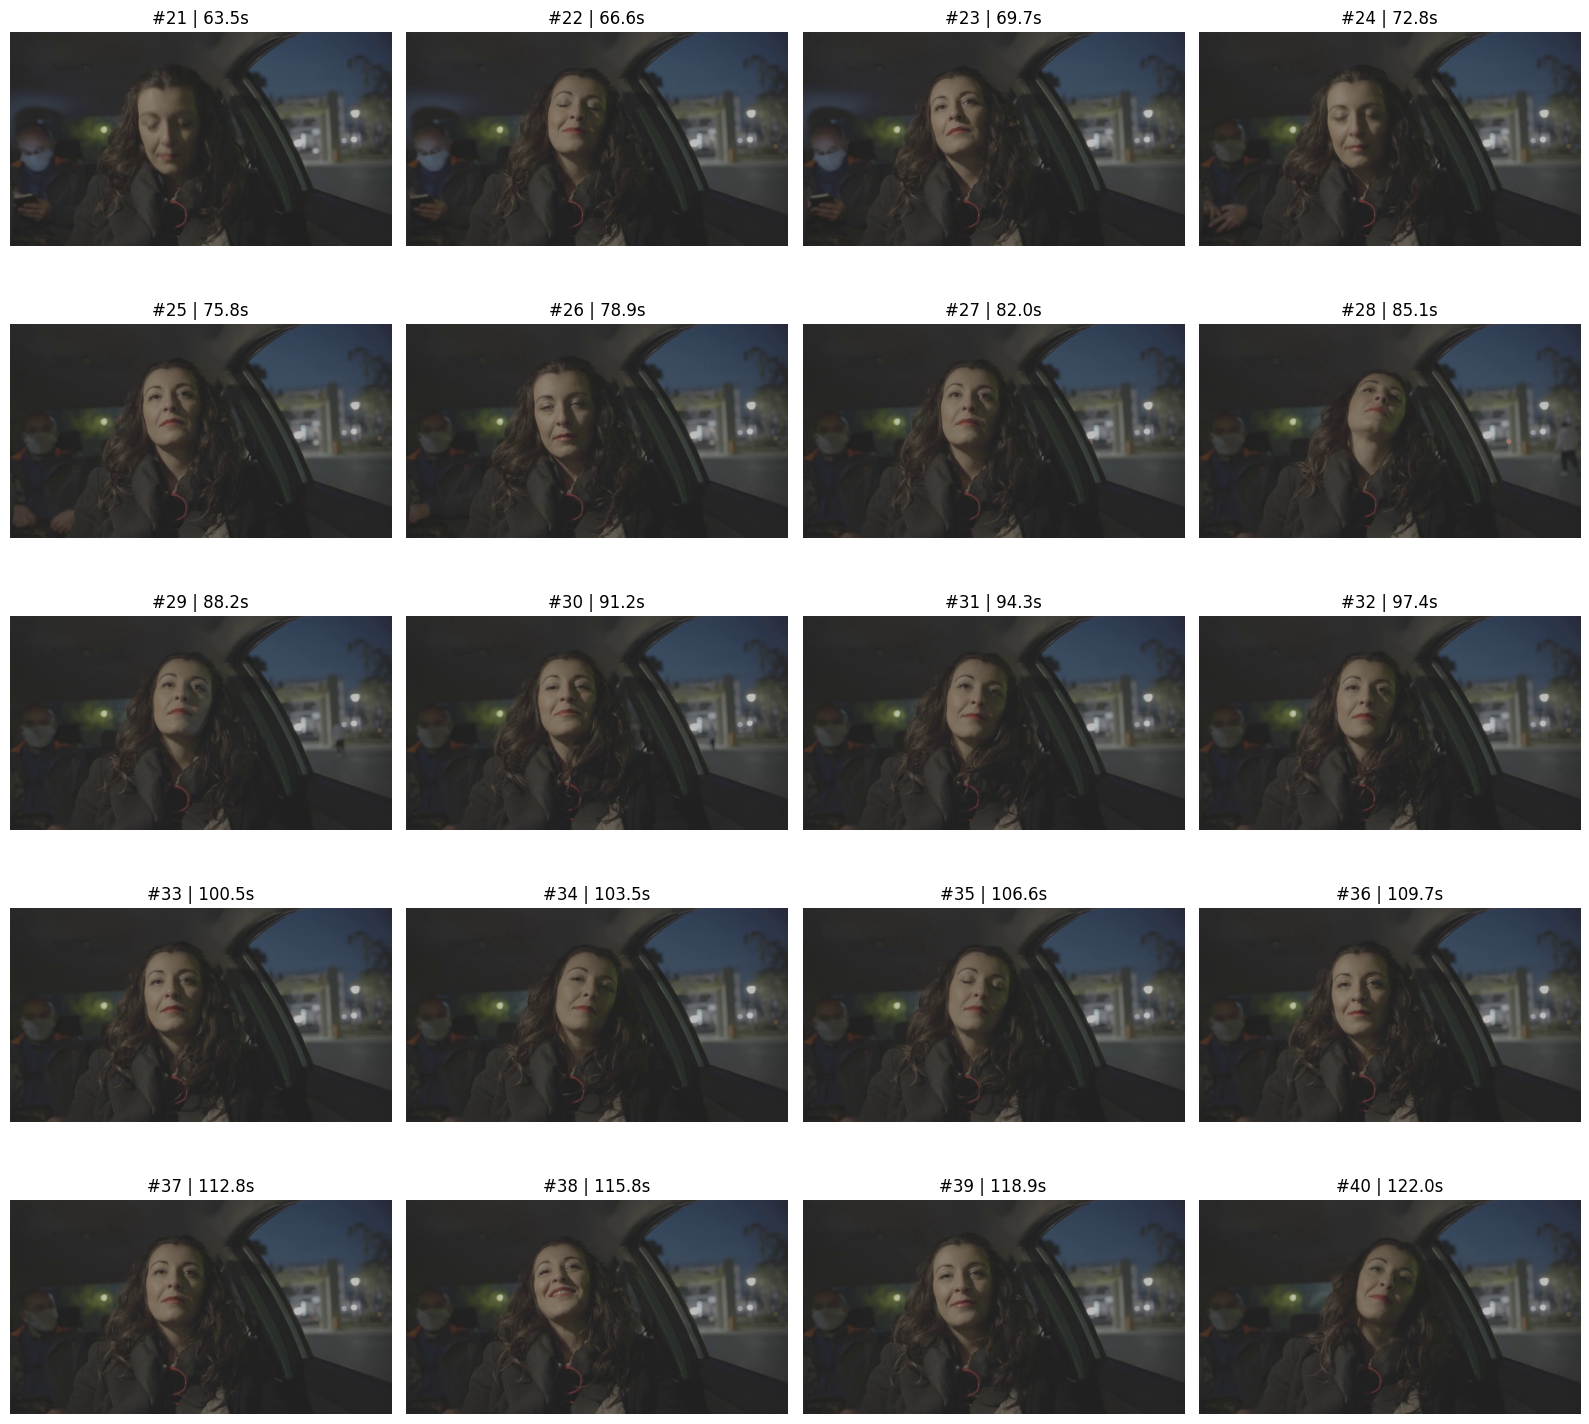

In [16]:
plt.figure(figsize=(16, 15))

for j, (t, img) in enumerate(test_images[20:]):

    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(5, 4, j + 1)
    plt.imshow(rgb)
    plt.title(f"#{j+21} | {t:.1f}s")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [17]:
# ==========================================
# MANUAL GROUND-TRUTH LABELS
# ==========================================

# 1  = OPEN
# 0  = CLOSED
# -1 = UNKNOWN / ambiguous

manual_labels = [
    1,  # 1
    0,  # 2
    1,  # 3
    1,  # 4
    0,  # 5
    1,  # 6
    1,  # 7
    1,  # 8
    1,  # 9
    1,  # 10

    1,  # 11
    1,  # 12
    1,  # 13
    1,  # 14
    1,  # 15
    1,  # 16
    1,  # 17
    1,  # 18
   -1,  # 19 - difficult upward pose
    1,  # 20 - OPEN, upward pose

    0,  # 21
    0,  # 22
    1,  # 23
    0,  # 24
    1,  # 25
    1,  # 26
    1,  # 27
   -1,  # 28 - difficult upward pose
    1,  # 29 - OPEN, upward pose
    1,  # 30

    1,  # 31
    1,  # 32
    1,  # 33
    1,  # 34
    0,  # 35
    1,  # 36
    1,  # 37
    1,  # 38
    1,  # 39
    1   # 40
]

print("Total samples:", len(manual_labels))
print("OPEN:", manual_labels.count(1))
print("CLOSED:", manual_labels.count(0))
print("UNKNOWN:", manual_labels.count(-1))

Total samples: 40
OPEN: 32
CLOSED: 6
UNKNOWN: 2


In [18]:
# ==========================================
# CALCULATE EAR FOR THE 40 LABELLED FRAMES
# ==========================================

labelled_results = []

for i, ((t, img), true_label) in enumerate(
    zip(test_images, manual_labels)
):

    # Convert frame to RGB
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    mp_img = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=rgb
    )

    # Detect face
    detection = face_landmarker.detect(mp_img)

    if detection.face_landmarks:

        lm = detection.face_landmarks[0]

        h_img, w_img, _ = img.shape

        left = calculate_ear(
            lm,
            LEFT_EYE,
            w_img,
            h_img
        )

        right = calculate_ear(
            lm,
            RIGHT_EYE,
            w_img,
            h_img
        )

        avg = (left + right) / 2

    else:
        avg = np.nan

    labelled_results.append({
        "sample": i + 1,
        "time_sec": t,
        "ground_truth": true_label,
        "EAR": avg
    })


labelled_df = pd.DataFrame(labelled_results)

labelled_df

,sample,time_sec,ground_truth,EAR
0,1,2.000000,1,0.306923
1,2,5.076923,0,0.092485
2,3,8.153846,1,0.358989
3,4,11.230769,1,0.291717
4,5,14.307692,0,0.103901
5,6,17.384615,1,0.333080
6,7,20.461538,1,0.280673
7,8,23.538462,1,0.325125
8,9,26.615385,1,0.291047
9,10,29.692308,1,0.345948


In [19]:
# ==========================================
# WEEK 5 EXPERIMENT:
# COMPARE DIFFERENT EAR THRESHOLDS
# ==========================================

thresholds = [0.15, 0.20, 0.25]

# Remove UNKNOWN samples (-1)
evaluation_df = labelled_df[
    labelled_df["ground_truth"] != -1
].copy()

comparison_results = []

for threshold in thresholds:

    # Prediction:
    # EAR < threshold  -> CLOSED (0)
    # EAR >= threshold -> OPEN (1)
    evaluation_df["prediction"] = (
        evaluation_df["EAR"] >= threshold
    ).astype(int)

    # Correct predictions
    correct = (
        evaluation_df["prediction"]
        == evaluation_df["ground_truth"]
    ).sum()

    total = len(evaluation_df)

    accuracy = correct / total * 100

    # FALSE OPEN:
    # Actually CLOSED, but predicted OPEN
    false_open = (
        (evaluation_df["ground_truth"] == 0) &
        (evaluation_df["prediction"] == 1)
    ).sum()

    # FALSE CLOSED:
    # Actually OPEN, but predicted CLOSED
    false_closed = (
        (evaluation_df["ground_truth"] == 1) &
        (evaluation_df["prediction"] == 0)
    ).sum()

    comparison_results.append({
        "EAR Threshold": threshold,
        "Correct": correct,
        "Total": total,
        "Accuracy (%)": round(accuracy, 2),
        "False Open": false_open,
        "False Closed": false_closed
    })


comparison_df = pd.DataFrame(comparison_results)

comparison_df

,EAR Threshold,Correct,Total,Accuracy (%),False Open,False Closed
0,0.15,38,38,100.00,0,0
1,0.20,37,38,97.37,0,1
2,0.25,34,38,89.47,0,4


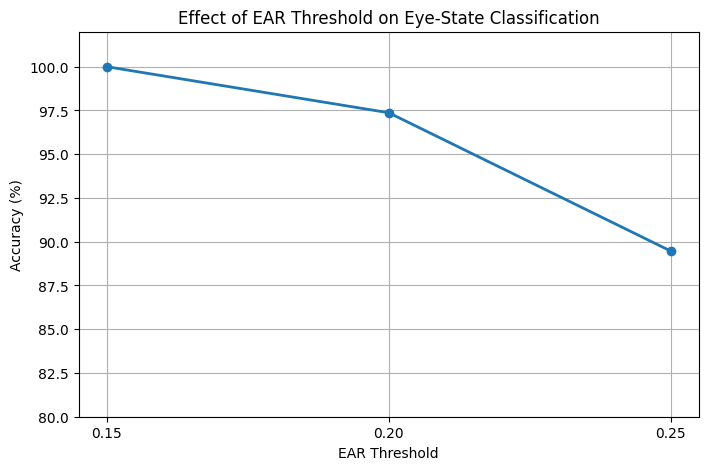

In [20]:
# ==========================================
# WEEK 5 THRESHOLD COMPARISON GRAPH
# ==========================================

plt.figure(figsize=(8, 5))

plt.plot(
    comparison_df["EAR Threshold"],
    comparison_df["Accuracy (%)"],
    marker="o",
    linewidth=2
)

plt.xlabel("EAR Threshold")
plt.ylabel("Accuracy (%)")
plt.title("Effect of EAR Threshold on Eye-State Classification")

plt.xticks(comparison_df["EAR Threshold"])
plt.ylim(80, 102)
plt.grid(True)

plt.show()

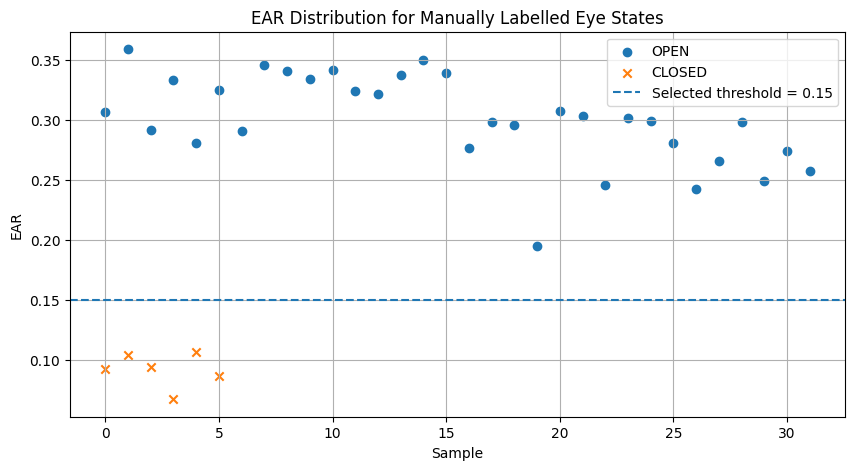

In [21]:
# ==========================================
# EAR VALUES FOR OPEN VS CLOSED EYES
# ==========================================

valid_df = labelled_df[
    labelled_df["ground_truth"] != -1
].copy()

open_ears = valid_df[
    valid_df["ground_truth"] == 1
]["EAR"]

closed_ears = valid_df[
    valid_df["ground_truth"] == 0
]["EAR"]

plt.figure(figsize=(10, 5))

plt.scatter(
    range(len(open_ears)),
    open_ears,
    marker="o",
    label="OPEN"
)

plt.scatter(
    range(len(closed_ears)),
    closed_ears,
    marker="x",
    label="CLOSED"
)

plt.axhline(
    y=0.15,
    linestyle="--",
    label="Selected threshold = 0.15"
)

plt.ylabel("EAR")
plt.xlabel("Sample")
plt.title("EAR Distribution for Manually Labelled Eye States")

plt.legend()
plt.grid(True)

plt.show()

In [22]:
# ==========================================
# FULL-FPS EAR ANALYSIS FOR BLINK DETECTION
# Analyse first 30 seconds
# ==========================================

START_TIME = 0
END_TIME = 30

EAR_THRESHOLD = 0.15

cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)

start_frame = int(START_TIME * fps)
end_frame = int(END_TIME * fps)

cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)

blink_data = []

frame_num = start_frame

while frame_num <= end_frame:

    success, current_frame = cap.read()

    if not success:
        break

    timestamp = frame_num / fps

    # Resize for faster processing
    small_frame = cv2.resize(
        current_frame,
        None,
        fx=0.5,
        fy=0.5
    )

    rgb = cv2.cvtColor(
        small_frame,
        cv2.COLOR_BGR2RGB
    )

    mp_img = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=rgb
    )

    detection = face_landmarker.detect(mp_img)

    if detection.face_landmarks:

        lm = detection.face_landmarks[0]

        h_img, w_img, _ = small_frame.shape

        left = calculate_ear(
            lm, LEFT_EYE, w_img, h_img
        )

        right = calculate_ear(
            lm, RIGHT_EYE, w_img, h_img
        )

        avg_ear = (left + right) / 2

        if avg_ear < EAR_THRESHOLD:
            eye_state = "CLOSED"
        else:
            eye_state = "OPEN"

        valid = True

    else:

        avg_ear = np.nan
        eye_state = "UNKNOWN"
        valid = False

    blink_data.append({
        "frame": frame_num,
        "time_sec": timestamp,
        "EAR": avg_ear,
        "eye_state": eye_state,
        "valid": valid
    })

    frame_num += 1


cap.release()

blink_df = pd.DataFrame(blink_data)

print("Finished!")
print("Frames analysed:", len(blink_df))
print()
print(blink_df["eye_state"].value_counts())

Finished!
Frames analysed: 751

eye_state
OPEN      608
CLOSED    143
Name: count, dtype: int64


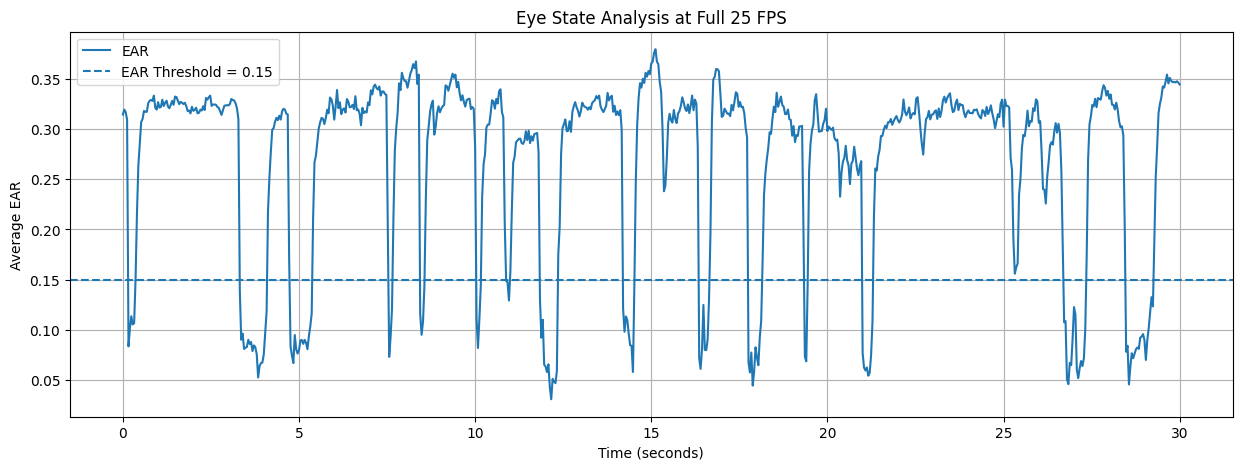

In [23]:
plt.figure(figsize=(15, 5))

plt.plot(
    blink_df["time_sec"],
    blink_df["EAR"],
    label="EAR"
)

plt.axhline(
    y=EAR_THRESHOLD,
    linestyle="--",
    label="EAR Threshold = 0.15"
)

plt.xlabel("Time (seconds)")
plt.ylabel("Average EAR")
plt.title("Eye State Analysis at Full 25 FPS")

plt.legend()
plt.grid(True)

plt.show()

In [24]:
# ==========================================
# DETECT EYE-CLOSURE EVENTS
# ==========================================

events = []

in_closure = False
start_time = None
start_frame = None

for i, row in blink_df.iterrows():

    state = row["eye_state"]

    # OPEN -> CLOSED
    if state == "CLOSED" and not in_closure:

        in_closure = True
        start_time = row["time_sec"]
        start_frame = int(row["frame"])

    # CLOSED -> OPEN
    elif state == "OPEN" and in_closure:

        end_time = row["time_sec"]
        end_frame = int(row["frame"])

        duration = end_time - start_time

        events.append({
            "start_sec": start_time,
            "end_sec": end_time,
            "duration_sec": duration,
            "start_frame": start_frame,
            "end_frame": end_frame
        })

        in_closure = False


events_df = pd.DataFrame(events)

print("Number of closure events:", len(events_df))

events_df

Number of closure events: 15


,start_sec,end_sec,duration_sec,start_frame,end_frame
0,0.16,0.40,0.24,4,10
1,3.32,4.12,0.80,83,103
2,4.76,5.40,0.64,119,135
3,7.56,7.68,0.12,189,192
4,8.44,8.60,0.16,211,215
5,10.04,10.20,0.16,251,255
6,10.88,11.00,0.12,272,275
7,11.84,12.36,0.52,296,309
8,14.20,14.56,0.36,355,364
9,16.36,16.68,0.32,409,417


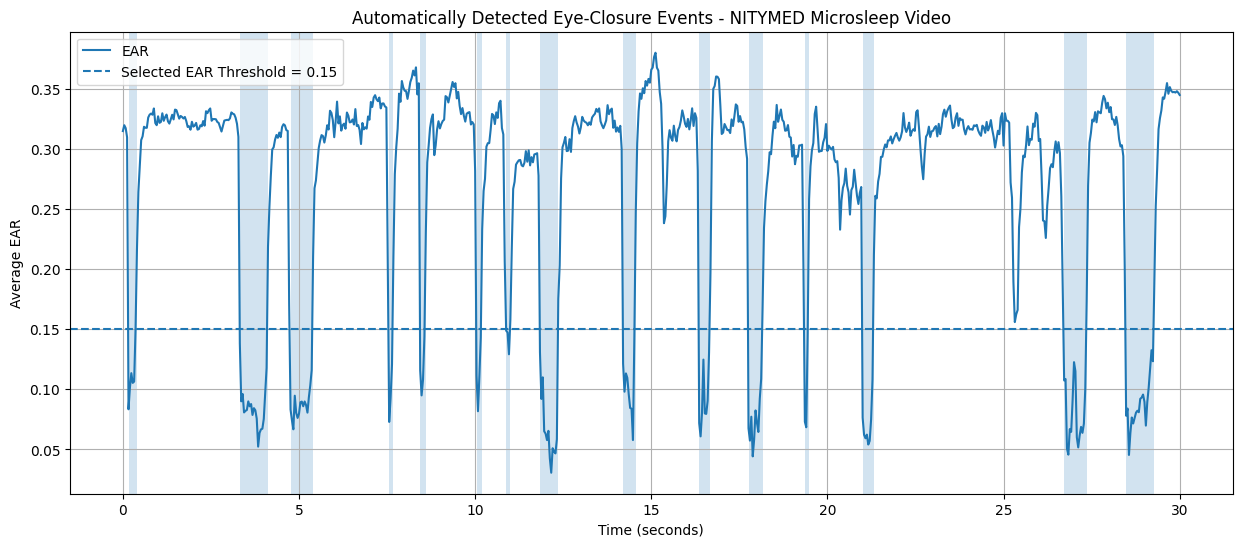

In [25]:
# ==========================================
# VISUALISE DETECTED EYE-CLOSURE EVENTS
# ==========================================

plt.figure(figsize=(15, 6))

# EAR signal
plt.plot(
    blink_df["time_sec"],
    blink_df["EAR"],
    label="EAR"
)

# Selected EAR threshold
plt.axhline(
    y=EAR_THRESHOLD,
    linestyle="--",
    label="Selected EAR Threshold = 0.15"
)

# Highlight every detected closure event
for _, event in events_df.iterrows():

    plt.axvspan(
        event["start_sec"],
        event["end_sec"],
        alpha=0.2
    )

plt.xlabel("Time (seconds)")
plt.ylabel("Average EAR")

plt.title(
    "Automatically Detected Eye-Closure Events "
    "- NITYMED Microsleep Video"
)

plt.legend()
plt.grid(True)

plt.show()

In [26]:
# ==========================================
# SG-2 OUTPUT PACKET FOR SG-4
# ==========================================

def create_sg2_output(row, closure_event=None):

    output = {
        "frame_id": int(row["frame"]),
        "timestamp_sec": round(float(row["time_sec"]), 3),

        "eye_state": row["eye_state"],

        "ear": (
            round(float(row["EAR"]), 3)
            if not np.isnan(row["EAR"])
            else None
        ),

        "ear_threshold": EAR_THRESHOLD,

        "valid": bool(row["valid"]),

        "closure_event": closure_event
    }

    return output

In [27]:
# Find one CLOSED frame
example_closed = blink_df[
    blink_df["eye_state"] == "CLOSED"
].iloc[0]

example_output = create_sg2_output(example_closed)

example_output

{'frame_id': 4,
 'timestamp_sec': 0.16,
 'eye_state': 'CLOSED',
 'ear': 0.083,
 'ear_threshold': 0.15,
 'valid': True,
 'closure_event': None}

In [28]:
# Take the first detected closure event
event = events_df.iloc[0]

closure_packet = {
    "event_type": "EYE_CLOSURE",
    "start_sec": round(float(event["start_sec"]), 3),
    "end_sec": round(float(event["end_sec"]), 3),
    "duration_sec": round(float(event["duration_sec"]), 3)
}

closure_packet

{'event_type': 'EYE_CLOSURE',
 'start_sec': 0.16,
 'end_sec': 0.4,
 'duration_sec': 0.24}

In [29]:
# Save Week 5 quantitative results

comparison_df.to_csv(
    "threshold_comparison.csv",
    index=False
)

events_df.to_csv(
    "closure_events.csv",
    index=False
)

print("Saved:")
print("- threshold_comparison.csv")
print("- closure_events.csv")

Saved:
- threshold_comparison.csv
- closure_events.csv


In [30]:
from google.colab import files

files.download("threshold_comparison.csv")
files.download("closure_events.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>